In [1]:
import numpy as np
import pandas as pd
from scipy import stats

### **Bài 1.** (4)
a) Đọc dữ liệu và cho biết có bao nhiêu thí sinh trong bảng dữ liệu. Tính điểm trung bình, độ lệch chuẩn, phương sai của điểm môn Ngữ Văn ("ngu_van") (0.5đ)

b) Chọn ngẫu nhiên 25 mẫu, sử dụng 25 mẫu này để ước lượng điểm trung bình của môn Ngữ Văn (sử dụng độ lệch chuẩn tính được bên trên làm độ lệch chuẩn quần thể) với độ tin cậy là 95%. (3đ)

c) Từ kết quả ước lượng bên trên hãy cho nhận xét về giá trị trung bình ước lượng và giá trị thật tính từ dữ liệu. (0.5đ)

In [ ]:
#a
import pandas as pd

# Đọc dữ liệu từ file CSV
data = pd.read_csv('dataKHXH.csv')

# Xem thông tin cơ bản của dữ liệu
print(data.info())

# Số lượng thí sinh trong bảng dữ liệu
num_students = data.shape[0]
print(f"Số thí sinh trong bảng dữ liệu: {num_students}")

# Tính điểm trung bình, độ lệch chuẩn, phương sai của môn Ngữ Văn
mean_ngu_van = data['ngu_van'].mean()
std_ngu_van = data['ngu_van'].std()
var_ngu_van = data['ngu_van'].var()

print(f"Điểm trung bình môn Ngữ Văn: {mean_ngu_van}")
print(f"Độ lệch chuẩn môn Ngữ Văn: {std_ngu_van}")
print(f"Phương sai môn Ngữ Văn: {var_ngu_van}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565243 entries, 0 to 565242
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   sbd           565243 non-null  int64  
 1   toan          565243 non-null  float64
 2   ngu_van       565243 non-null  float64
 3   ngoai_ngu     565243 non-null  float64
 4   lich_su       565243 non-null  float64
 5   dia_li        565243 non-null  float64
 6   gdcd          565243 non-null  float64
 7   ma_ngoai_ngu  565243 non-null  object 
dtypes: float64(6), int64(1), object(1)
memory usage: 34.5+ MB
None
Số thí sinh trong bảng dữ liệu: 565243
Điểm trung bình môn Ngữ Văn: 7.018640451982597
Độ lệch chuẩn môn Ngữ Văn: 1.3207685875545687
Phương sai môn Ngữ Văn: 1.7444296618708905


In [ ]:
#b
import scipy.stats as stats
import numpy as np

# Lấy ngẫu nhiên 25 mẫu
sample_data = data.sample(n=25, random_state=15)

# Tính độ lệch chuẩn mẫu
sample_std = sample_data['ngu_van'].std()

# Tính độ tin cậy 95% cho điểm trung bình
mean_sample = sample_data['ngu_van'].mean()

# Tính khoảng tin cậy 95% (Sử dụng độ lệch chuẩn mẫu làm ước tính)
n = len(sample_data)
z = stats.norm.ppf(0.975)  # Z-value cho độ tin cậy 95%
margin_of_error = z * (sample_std / np.sqrt(n))

# Tính khoảng tin cậy
lower_bound = mean_sample - margin_of_error
upper_bound = mean_sample + margin_of_error

print(f"Điểm trung bình mẫu: {mean_sample}")
print(f"Khoảng tin cậy 95% cho điểm trung bình: ({lower_bound}, {upper_bound})")


Điểm trung bình mẫu: 7.0
Khoảng tin cậy 95% cho điểm trung bình: (6.344436726497621, 7.655563273502379)


Gọi $\mu$ là điểm trung bình môn Ngữ Văn của tập dữ liệu. Ta có, $\bar{x}=7.00$ là điểm trung bình môn Ngữ Văn của 25 thí sinh.

Độ tin cậy $95\% = 1 - \alpha$ => $\alpha=0.05$

Ta có $n = 25 < 30$. => Tuy nhiên đề yêu càu sử dụng độ lệch chuẩn của quần thể => ta sấp sỉ phân phối trên với phân phối z không quan tâm n
$$\bigg(\bar{x} - z_{1-\frac{\alpha}{2}}\frac{s}{\sqrt{n}},\bar{x}+z_{1-\frac{\alpha}{2}}\frac{s}{\sqrt{n}}\bigg)$$
Trong đó, $\alpha = 0.05$, $z_{1-\frac{\alpha}{2}}=1.96$, $\bar{x}=7.00$, $s=1.32$

**(0.5đ)** Vậy khoảng giá trị trung bình thật là: (6.45:7.55) với khoảng tin cậy 95%

c) Ta nhận thấy giá trị trung bình của tập dữ liệu nằm trong khoảng ước lượng, điều này cho thấy khoảng ước lượng đáng tin cậy. Tuy nhiên tại số lượng mẫu được lấy ra ít nên sai số lớn


In [19]:
print(f"Giá trị trung bình thực tế của môn Ngữ Văn: {mean_ngu_van}")
if lower_bound <= mean_ngu_van <= upper_bound:
    print("Giá trị trung bình thật nằm trong khoảng tin cậy.")
else:
    print("Giá trị trung bình thật không nằm trong khoảng tin cậy.")


Giá trị trung bình thực tế của môn Ngữ Văn: 7.018640451982597
Giá trị trung bình thật nằm trong khoảng tin cậy.


### **Bài 2**
Lấy ngẫu nhiên 1000 mẫu dữ liệu từ dữ liệu gốc, có nhận xét cho rằng: "Có từ 75% thí sinh khối KHXH có điểm Toán trên trung bình". Bạn có thể đưa ra kết luận gì nhận xét trên dựa vào 1000 mẫu vừa lấy được với mức ý nghĩa 5%? (4đ)

In [5]:
n = 1000
sample = data.sample(n, random_state=15)

In [6]:
# 0.25đ
gte5 = sample[sample['toan'] >= 5].shape[0]
print("Số thí sinh trên điểm trung bình: ",gte5)
p_mu = gte5/n
print("Tỉ lệ thí sinh trên trung bình: ",p_mu)

Số thí sinh trên điểm trung bình:  746
Tỉ lệ thí sinh trên trung bình:  0.746


Gọi $p$ là thí sinh có điểm Toán trên trung bình. Ta cần kiểm định giả thuyết:

$H_0 : p \ge 0.75$: Có từ 75% thí sinh khối KHXH có điểm Toán trên trung bình

$H_1: p < 0.75$: Tỉ lệ thí sinh khối KHXH có điểm Toán trên trung bình thấp hơn 75%

Mức ý nghĩa là: $5\% => \alpha=0.05$

In [7]:
p = 0.75
alpha = 5/100

- Điểm thi của các thí sinh trên trung bình hay không là độc lập với nhau nên tỉ lệ thí sinh đạt điểm trên trung bình tuân theo phân phối nhị thức.
- Ta có
    - $\hat{p} = 0.75$ là tỷ lệ thí sinh có điểm Toán trên trung bình.
    - $n=1000 > 30$,
    - $\hat{p}=0.75$, $n\hat{p}=1000\times0.75=750 \geq 5$
    - $n(1-\hat{p}) = 1000(1-0.75)= 250 \geq 5$
    
=> Vậy phân phối nhị thức của tỷ lệ mẫu có thể xấp xỉ bằng phân phối chuẩn.
$$z=\frac{\hat{p}-p}{\sqrt{\frac{pq}{n}}}$$

In [8]:
# 0.25đ
z = (p_mu - p)/np.sqrt(p_mu*(1-p_mu)/n)
print("z =", z)

z = -0.29058535263133406


Vì $H_1$ là $<$ là kiểm định đuôi trái nên ta có
$$p_{values} = P(Z<z)$$

In [9]:
p_value = stats.norm.cdf(z)
print("p_value là: ", p_value)
if p_value < alpha:
    print('Reject H0')
else:
    print('Accept H0')

p_value là:  0.3856842319066385
Accept H0


Vì $p_{value} = 0.386 > \alpha=0.05$ nên ta kết luận: không có đủ bằng chứng để bác bỏ nhận xét trên với mức ý nghĩa 5%$

### **Bài 3** (2đ)

Khảo sát điểm trung bình các bài lab của một môn học X(\$) và điểm thi cuối kỳ Y(\$) trong một môn học. Khảo sát ngẫu nhiên 8 sinh viên, ta thu được bảng số liệu sau:

| Điểm trung bình các lab          | 7.5     | 5.5      | 3.0      | 8      | 9      | 1      | 6      |  6      |
| :----------: | :-----: | :------: | :------: | :------: | :------: | :------: | :------: |:------: |
| Điểm thi cuối kỳ       | **8**  | **6.5**  | **4**  | **7.5**  | **9.5**  | **3**  | **5**  | **6**  |


a. Dựa vào bảng dữ liệu trên cho biết có xây dựng được mô hình hồi quy hay không? Nếu có hãy xây dựng mô hình hồi quy để ước điểm trung bình các bài lab dựa theo điểm thi cuối kỳ. (1đ)

b. Dự đoán điểm trung bình các bài lab của một sinh viên có điểm thi cuối kỳ là 6.5. (1đ)

In [10]:
X = np.array([8.0, 6.5, 4.0, 7.5, 9.5, 3.0, 5.0, 6.0])
Y = np.array([7.5, 5.5, 3.0, 8.0, 9.0, 1.0, 6.0, 6.0])

Ta có biến phụ thuộc là điểm trung bình các bài lab và biến giải thích là điểm cuối kỳ.

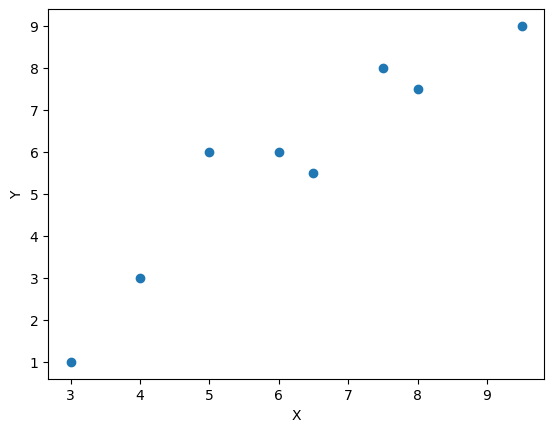

In [11]:
# plot X,Y
import matplotlib.pyplot as plt
plt.scatter(X,Y)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [12]:
# covariance và correlation coefficient của X và Y
cov = np.cov(X,Y)
print("Covariance: \n", cov)
corr = np.corrcoef(X,Y)
print("Correlation coefficient: \n", corr)

Covariance: 
 [[4.63839286 5.375     ]
 [5.375      7.        ]]
Correlation coefficient: 
 [[1.         0.94329099]
 [0.94329099 1.        ]]


**(0.5đ)**

Ta thấy hệ số tương quan của $X$ và $Y$ là $0.93$ nên mối quan thuận, tức là nếu $X$ tăng thì $Y$ cũng sẽ tăng.

Vậy có thể xây dựng mô hình hồi quy giữa $X$ và $Y$: $$Y=\beta_0+\beta_1X$$

In [13]:
x_bar = np.mean(X)
y_bar = np.mean(Y)
print("x_bar = ", x_bar)
print("y_bar = ", y_bar)
beta_1 = np.sum((X-x_bar)*(Y-y_bar))/np.sum((X-x_bar)**2)
beta_0 = y_bar - beta_1*x_bar
print("beta_1 = ", beta_1)
print("beta_0 = ", beta_0)

x_bar =  6.1875
y_bar =  5.75
beta_1 =  1.1588065447545717
beta_0 =  -1.4201154956689122


**(0.5đ)** Vậy mô hình hồi quy giữ điểm trung bình các bài lab $Y$ và điểm thi cuối kỳ $X$ là: $$Y\approx-1,42+1,15X$$

b. Dự đoán điểm điểm thi cuối kỳ biết điểm trung bình các bài lab của một sinh viên là 6.2

**(0.5đ)** Điểm trung bình các bài lab 6.2 => $Y=6.2$. Thay $Y$ vào công thức hồi quy ta xây dựng bên trên.

In [14]:
Y1 = 6.15
X1 = (Y1-beta_0)/beta_1
print("X1 = ", X1)

X1 =  6.532682724252492


**(0.5đ)** Vậy điểm trung bình các lab của bạn sinh viên này khoảng 6.5đ